# Policy comparison

Loads every `pulls-*.csv` in `logs/`, plots cumulative reward and oracle-agreement over time.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ORACLE_LABEL = 'oracle'

candidates = [Path.cwd() / 'logs', Path.cwd() / 'RMAB_cwh' / 'logs', Path('C:/dev/cw_or_env/RMAB_cwh/logs')]
LOG_DIR = next((p for p in candidates if p.exists()), None)
if LOG_DIR is None:
    raise RuntimeError(f'no logs dir found. cwd={Path.cwd()}, tried={candidates}')
print(f'LOG_DIR = {LOG_DIR}')

def label_from(path: Path) -> str:
    parts = path.stem.split('-')
    return 'llm' if len(parts) == 2 else '-'.join(parts[1:-1])

files = sorted(LOG_DIR.glob('pulls-*.csv'))
print(f'found {len(files)} csv(s):')
for p in files:
    print(f'  {p.name}')
if not files:
    raise RuntimeError(f'no pulls-*.csv files in {LOG_DIR}')

dfs = {label_from(p): pd.read_csv(p) for p in files}
print()
for label, df in dfs.items():
    if len(df):
        print(f'{label:14s}  pulls={len(df):4d}  final={df["total_value"].iloc[-1]:.4f}')
    else:
        print(f'{label:14s}  empty')

LOG_DIR = c:\dev\cw_or_env\RMAB_cwh\logs
found 7 csv(s):
  pulls-20260425T154007Z.csv
  pulls-greedy-20260425T154837Z.csv
  pulls-oracle-20260425T154837Z.csv
  pulls-random-20260425T154832Z.csv
  pulls-random-20260425T154837Z.csv
  pulls-roundrobin-20260425T154837Z.csv
  pulls-sliding_ucb-20260425T154837Z.csv

llm             pulls= 200  final=141.0597
greedy          pulls= 200  final=170.9683
oracle          pulls= 200  final=434.3148
random          pulls= 200  final=202.7664
roundrobin      pulls= 200  final=161.9478
sliding_ucb     pulls= 200  final=300.2336


## 1. Cumulative reward across pulls

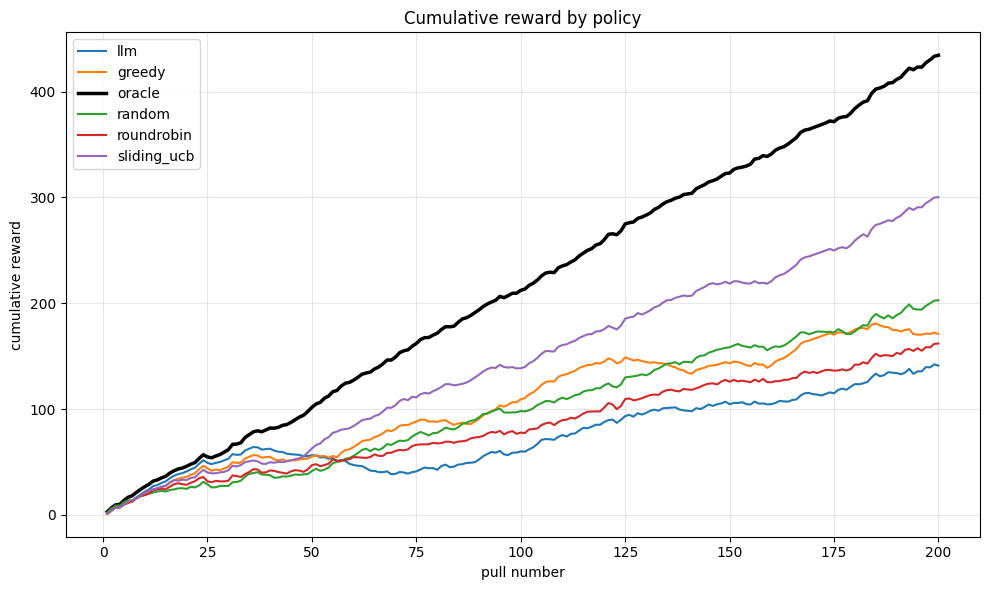

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, df in dfs.items():
    if len(df) == 0:
        continue
    style = {'linewidth': 2.5, 'color': 'black'} if label == ORACLE_LABEL else {'linewidth': 1.5}
    ax.plot(df['pull_number'], df['total_value'], label=label, **style)
ax.set_xlabel('pull number')
ax.set_ylabel('cumulative reward')
ax.set_title('Cumulative reward by policy')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Cumulative count of pulls that hit the oracle's machine

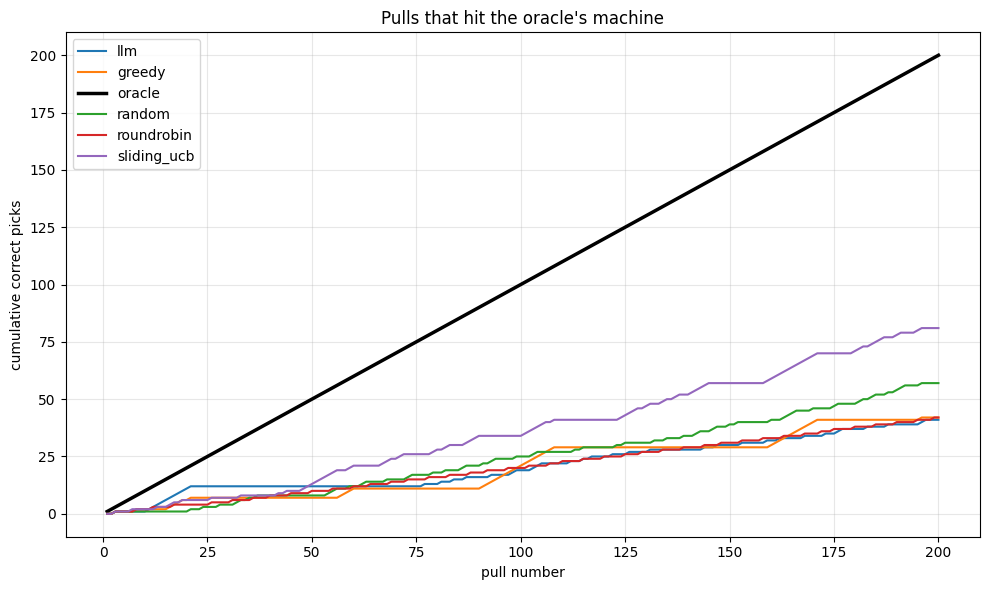

In [3]:
if ORACLE_LABEL not in dfs:
    raise RuntimeError(f'no oracle csv found in {LOG_DIR}')

oracle_picks = dfs[ORACLE_LABEL].set_index('pull_number')['pulled_machine']

fig, ax = plt.subplots(figsize=(10, 6))
for label, df in dfs.items():
    if len(df) == 0:
        continue
    picks = df.set_index('pull_number')['pulled_machine'].reindex(oracle_picks.index)
    correct = (picks == oracle_picks).fillna(False).cumsum()
    style = {'linewidth': 2.5, 'color': 'black'} if label == ORACLE_LABEL else {'linewidth': 1.5}
    ax.plot(correct.index, correct.values, label=label, **style)
ax.set_xlabel('pull number')
ax.set_ylabel('cumulative correct picks')
ax.set_title("Pulls that hit the oracle's machine")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In [4]:
rows = []
for label, df in dfs.items():
    if len(df) == 0:
        continue
    picks = df.set_index('pull_number')['pulled_machine'].reindex(oracle_picks.index)
    n = picks.notna().sum()
    correct = (picks == oracle_picks).sum()
    rows.append({
        'policy': label,
        'pulls': len(df),
        'final_total': df['total_value'].iloc[-1],
        'oracle_match_rate': correct / n if n else float('nan'),
    })
summary = pd.DataFrame(rows).sort_values('final_total', ascending=False)
summary

,policy,pulls,final_total,oracle_match_rate
2,oracle,200,434.314757,1.000
5,sliding_ucb,200,300.233610,0.405
3,random,200,202.766352,0.285
1,greedy,200,170.968332,0.210
4,roundrobin,200,161.947788,0.210
0,llm,200,141.059689,0.205
